In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from rdkit.Chem import PandasTools
from rdkit import rdBase
from rdkit import Chem
from rdkit.Chem.rdmolfiles import SmilesWriter
from pathlib import Path
from rdkit.Chem import Descriptors, Draw, PandasTools
from warnings import filterwarnings
from rdkit import DataStructs
from rdkit.Chem import MACCSkeys
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import rdMHFPFingerprint
from rdkit.Chem import MolFromSmiles
from rdkit.Chem import SaltRemover
from molvs import validate_smiles
from molvs import standardize_smiles
from molvs import charge
from FP import *
import mols2grid

In [2]:
descriptor_names = list(Descriptors.rdMolDescriptors.Properties.GetAvailableProperties())

get_descriptors = Descriptors.rdMolDescriptors.Properties(descriptor_names)

In [3]:
def smi_to_descriptors(smile):
    mol = Chem.MolFromSmiles(smile)
    descriptors = []
    if mol:
        descriptors = np.array(get_descriptors.ComputeProperties(mol))
    return descriptors

In [4]:
def gen_canonical(smiles, ):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True, )


In [5]:
def check_smiles(smi):
    try:
        Chem.MolFromSmiles(smi, sanitize=True)
        return True
    except:
        return False
def has_carbon(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    return any(atom.GetSymbol() == "C" for atom in mol.GetAtoms())

def heavy_atom_count(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol.GetNumHeavyAtoms() if mol else 0

In [6]:
def pass_size_filter(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return False
    hva = mol.GetNumHeavyAtoms()
    has_carbon = any(a.GetSymbol() == "C" for a in mol.GetAtoms())
    return (hva >= 5) and has_carbon

def is_multifragment(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return True  # treat invalid SMILES as bad
    return len(Chem.GetMolFrags(mol)) > 1

In [7]:
import numpy as np
from rdkit import DataStructs

def similarity_stats(fps, bins=50):
    n = len(fps)
    
    total = 0.0
    count = 0
    
    hist = np.zeros(bins)
    
    for i in range(n):
        sims = DataStructs.BulkTanimotoSimilarity(fps[i], fps[i+1:])
        
        for s in sims:
            total += s
            count += 1
            
            # histogram binning (0–1 range)
            bin_idx = min(int(s * bins), bins - 1)
            hist[bin_idx] += 1
    
    mean_sim = total / count
    diversity = 1 - mean_sim
    
    return mean_sim, diversity, hist

### Cleaning of Datasets 
FDA+KEGG as non-toxic and TOXNET+T3DB as toxic

In [8]:
df_combined = pd.read_csv("training_set.smi", header=None, sep="\t")
df_combined.columns = ["SMILES", "Name","Toxicity"  ]
df_combined

,SMILES,Name,Toxicity
0,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,DB00014,0
1,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1C...,DB00035,0
2,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,DB00050,0
3,C/C=C/C[C@@H](C)[C@H](O)[C@@H]1/C(O)=N/[C@@H](...,DB00091,0
4,NCCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1CSSC[C...,DB00093,0
...,...,...,...
8942,C[C@@H](N)NCCO,ZINC98359253,1
8943,O=P(O)(O)OC(c1ccccc1)c1ccccc1,ZINC98359257,1
8944,CCCCO[C@@H](C)OC[C@@H](C)O,ZINC98359263,1
8945,C=C(CCN(CC)CC)C(=O)O,ZINC98359322,1


In [9]:
df_combined["CanonicalSMILES"] = df_combined["SMILES"].apply(gen_canonical)

In [10]:
df_combined[df_combined["SMILES"] != df_combined["CanonicalSMILES"]]

,SMILES,Name,Toxicity,CanonicalSMILES
11,O=C(O)CCCC[C@@H]1SC[C@@H]2NC(=O)N[C@H]12,DB00121,0,O=C(O)CCCC[C@@H]1SC[C@@H]2NC(=O)N[C@@H]21
61,C[C@@H](Cc1ccc(O)c(O)c1)[C@H](C)Cc1ccc(O)c(O)c1,DB00179,0,C[C@H](Cc1ccc(O)c(O)c1)[C@@H](C)Cc1ccc(O)c(O)c1
119,CN1[C@H]2CC[C@@H]1C[C@H](OC(c1ccccc1)c1ccccc1)C2,DB00245,0,CN1[C@@H]2CC[C@H]1C[C@@H](OC(c1ccccc1)c1ccccc1)C2
146,CC1(C)O[C@H]2CO[C@]3(COS(N)(=O)=O)OC(C)(C)O[C@...,DB00273,0,CC1(C)O[C@H]2[C@H](CO[C@]3(COS(N)(=O)=O)OC(C)(...
150,C[C@H]1CNc2c(cccc2S(=O)(=O)N[C@@H](CCCN=C(N)N)...,DB00278,0,C[C@@H]1CCN(C(=O)[C@H](CCCN=C(N)N)NS(=O)(=O)c2...
...,...,...,...,...
8870,C=C[C@H]1CN2CC[C@H]1C[C@H]2[C@H](O)[C@@H]1CC=N...,ZINC88465948,1,C=C[C@H]1CN2CC[C@H]1C[C@H]2[C@H](O)[C@@H]1CC=N...
8907,CCC[C@@H]1N=C(C)[C@@H]2C(=O)N=C(c3cc(S(=O)(=O)...,ZINC95869752,1,CCC[C@@H]1N=C(C)[C@@H]2C(=O)N=C(c3cc(S(=O)(=O)...
8917,CCCC[C@H](CC)C/C(C(=O)O)=C(\C[C@H](CC)CCCC)C(=O)O,ZINC95936052,1,CCCC[C@@H](CC)C/C(C(=O)O)=C(\C[C@@H](CC)CCCC)C...
8930,CCCC[C@H](CC)Cc1c(C[C@H](CC)CCCC)c(C(=O)O)c(C[...,ZINC98087491,1,CCCC[C@@H](CC)Cc1c(C[C@@H](CC)CCCC)c(C(=O)O)c(...


In [11]:
conflicting_smiles = (df_combined.groupby("CanonicalSMILES")["Toxicity"].nunique().loc[lambda x: x > 1].index)

len(conflicting_smiles)

725

In [12]:
df_combined_noConf = df_combined[~df_combined["CanonicalSMILES"].isin(conflicting_smiles)]
df_combined_noConf

,SMILES,Name,Toxicity,CanonicalSMILES
0,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,DB00014,0,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...
1,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1C...,DB00035,0,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1C...
2,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,DB00050,0,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...
3,C/C=C/C[C@@H](C)[C@H](O)[C@@H]1/C(O)=N/[C@@H](...,DB00091,0,C/C=C/C[C@@H](C)[C@H](O)[C@@H]1/C(O)=N/[C@@H](...
4,NCCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1CSSC[C...,DB00093,0,NCCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1CSSC[C...
...,...,...,...,...
8942,C[C@@H](N)NCCO,ZINC98359253,1,C[C@@H](N)NCCO
8943,O=P(O)(O)OC(c1ccccc1)c1ccccc1,ZINC98359257,1,O=P(O)(O)OC(c1ccccc1)c1ccccc1
8944,CCCCO[C@@H](C)OC[C@@H](C)O,ZINC98359263,1,CCCCO[C@@H](C)OC[C@@H](C)O
8945,C=C(CCN(CC)CC)C(=O)O,ZINC98359322,1,C=C(CCN(CC)CC)C(=O)O


In [13]:
df_combined_noConf["valid_smiles"] = df_combined_noConf["CanonicalSMILES"].apply(check_smiles)

bad_df = df_combined_noConf[~df_combined_noConf["valid_smiles"]]
bad_df.head()

/tmp/ipykernel_509778/3624318369.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_combined_noConf["valid_smiles"] = df_combined_noConf["CanonicalSMILES"].apply(check_smiles)


,SMILES,Name,Toxicity,CanonicalSMILES,valid_smiles


In [14]:
df_combined_noConf = df_combined_noConf[df_combined_noConf["valid_smiles"]]
df_combined_noConf

,SMILES,Name,Toxicity,CanonicalSMILES,valid_smiles
0,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,DB00014,0,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,True
1,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1C...,DB00035,0,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1C...,True
2,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,DB00050,0,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,True
3,C/C=C/C[C@@H](C)[C@H](O)[C@@H]1/C(O)=N/[C@@H](...,DB00091,0,C/C=C/C[C@@H](C)[C@H](O)[C@@H]1/C(O)=N/[C@@H](...,True
4,NCCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1CSSC[C...,DB00093,0,NCCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1CSSC[C...,True
...,...,...,...,...,...
8942,C[C@@H](N)NCCO,ZINC98359253,1,C[C@@H](N)NCCO,True
8943,O=P(O)(O)OC(c1ccccc1)c1ccccc1,ZINC98359257,1,O=P(O)(O)OC(c1ccccc1)c1ccccc1,True
8944,CCCCO[C@@H](C)OC[C@@H](C)O,ZINC98359263,1,CCCCO[C@@H](C)OC[C@@H](C)O,True
8945,C=C(CCN(CC)CC)C(=O)O,ZINC98359322,1,C=C(CCN(CC)CC)C(=O)O,True


In [15]:
df_combined_noConf.groupby("CanonicalSMILES").nunique()

,SMILES,Name,Toxicity,valid_smiles
CanonicalSMILES,,,,
Br/C=C/Cc1ccccc1,1,1,1,1
Br/C=C/c1ccccc1,1,1,1,1
BrB(Br)Br,1,1,1,1
BrBr,1,1,1,1
BrC(Br)(Br)Br,1,2,1,1
...,...,...,...,...
c1coc(CNc2ncnc3[nH]cnc23)c1,1,1,1,1
c1n[nH]cc1Cc1cn[nH]c1,1,1,1,1
c1nc2c([nH]1)CCCC2,1,1,1,1


In [16]:
df_combined_noConf.drop_duplicates(inplace=True, keep="first", subset="CanonicalSMILES")
df_combined_noConf

,SMILES,Name,Toxicity,CanonicalSMILES,valid_smiles
0,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,DB00014,0,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,True
1,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1C...,DB00035,0,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1C...,True
2,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,DB00050,0,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,True
3,C/C=C/C[C@@H](C)[C@H](O)[C@@H]1/C(O)=N/[C@@H](...,DB00091,0,C/C=C/C[C@@H](C)[C@H](O)[C@@H]1/C(O)=N/[C@@H](...,True
4,NCCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1CSSC[C...,DB00093,0,NCCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1CSSC[C...,True
...,...,...,...,...,...
8942,C[C@@H](N)NCCO,ZINC98359253,1,C[C@@H](N)NCCO,True
8943,O=P(O)(O)OC(c1ccccc1)c1ccccc1,ZINC98359257,1,O=P(O)(O)OC(c1ccccc1)c1ccccc1,True
8944,CCCCO[C@@H](C)OC[C@@H](C)O,ZINC98359263,1,CCCCO[C@@H](C)OC[C@@H](C)O,True
8945,C=C(CCN(CC)CC)C(=O)O,ZINC98359322,1,C=C(CCN(CC)CC)C(=O)O,True


In [17]:
df_combined_clean = df_combined_noConf[df_combined_noConf["CanonicalSMILES"].apply(has_carbon)]
df_combined_clean

,SMILES,Name,Toxicity,CanonicalSMILES,valid_smiles
0,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,DB00014,0,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,True
1,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1C...,DB00035,0,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1C...,True
2,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,DB00050,0,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,True
3,C/C=C/C[C@@H](C)[C@H](O)[C@@H]1/C(O)=N/[C@@H](...,DB00091,0,C/C=C/C[C@@H](C)[C@H](O)[C@@H]1/C(O)=N/[C@@H](...,True
4,NCCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1CSSC[C...,DB00093,0,NCCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1CSSC[C...,True
...,...,...,...,...,...
8942,C[C@@H](N)NCCO,ZINC98359253,1,C[C@@H](N)NCCO,True
8943,O=P(O)(O)OC(c1ccccc1)c1ccccc1,ZINC98359257,1,O=P(O)(O)OC(c1ccccc1)c1ccccc1,True
8944,CCCCO[C@@H](C)OC[C@@H](C)O,ZINC98359263,1,CCCCO[C@@H](C)OC[C@@H](C)O,True
8945,C=C(CCN(CC)CC)C(=O)O,ZINC98359322,1,C=C(CCN(CC)CC)C(=O)O,True


In [18]:
df_combined_clean = df_combined_clean[df_combined_clean["CanonicalSMILES"].apply(heavy_atom_count) >= 5]
df_combined_clean

,SMILES,Name,Toxicity,CanonicalSMILES,valid_smiles
0,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,DB00014,0,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,True
1,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1C...,DB00035,0,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1C...,True
2,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,DB00050,0,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,True
3,C/C=C/C[C@@H](C)[C@H](O)[C@@H]1/C(O)=N/[C@@H](...,DB00091,0,C/C=C/C[C@@H](C)[C@H](O)[C@@H]1/C(O)=N/[C@@H](...,True
4,NCCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1CSSC[C...,DB00093,0,NCCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1CSSC[C...,True
...,...,...,...,...,...
8942,C[C@@H](N)NCCO,ZINC98359253,1,C[C@@H](N)NCCO,True
8943,O=P(O)(O)OC(c1ccccc1)c1ccccc1,ZINC98359257,1,O=P(O)(O)OC(c1ccccc1)c1ccccc1,True
8944,CCCCO[C@@H](C)OC[C@@H](C)O,ZINC98359263,1,CCCCO[C@@H](C)OC[C@@H](C)O,True
8945,C=C(CCN(CC)CC)C(=O)O,ZINC98359322,1,C=C(CCN(CC)CC)C(=O)O,True


In [19]:
checkingSmiles = df_combined_clean['CanonicalSMILES'].apply(validate_smiles)
CompoundsWiThSalts = checkingSmiles[checkingSmiles.map(lambda d: len(d)) > 0]
indexRemove = CompoundsWiThSalts.index
print(len(CompoundsWiThSalts))
indexRemove

18


Index([5135, 6793, 6806, 6817, 6995, 7042, 7112, 7139, 7149, 7187, 7206, 7266,
       7674, 7792, 7800, 8030, 8218, 8341],
      dtype='int64')

In [ ]:
#salts=df_combined_clean.loc[indexRemove]
#mols2grid.display(salts,smiles_col="CanonicalSMILES",subset=["img","Name","Toxicity", ],selection=False, addStereoAnnotation=True, size=(300, 250))

In [20]:
df_combined_clean[df_combined_clean["CanonicalSMILES"].apply(is_multifragment)]

,SMILES,Name,Toxicity,CanonicalSMILES,valid_smiles


In [21]:
df_combined_clean.groupby("Name").nunique()

,SMILES,Toxicity,CanonicalSMILES,valid_smiles
Name,,,,
D00006,1,1,1,1
D00027,1,1,1,1
D00034,1,1,1,1
D00048,1,1,1,1
D00065,1,1,1,1
...,...,...,...,...
ZINC98359253,1,1,1,1
ZINC98359257,1,1,1,1
ZINC98359263,1,1,1,1


In [ ]:
df_combined_clean.groupby("CanonicalSMILES").nunique()

#### Generation of 1D/2D descriptors

In [23]:
%%capture
df = df_combined_clean.copy()
df["1Ddescriptors"] = df["SMILES"].apply(smi_to_descriptors)
df = df[['Name','1Ddescriptors','Toxicity' ]]
df.to_pickle("1DDescriptors.csv")

In [24]:
compound_df = df_combined_clean.copy()
compound_df

,SMILES,Name,Toxicity,CanonicalSMILES,valid_smiles
0,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,DB00014,0,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...,True
1,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1C...,DB00035,0,N=C(N)NCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1C...,True
2,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,DB00050,0,CC(=O)N[C@H](Cc1ccc2ccccc2c1)C(=O)N[C@H](Cc1cc...,True
3,C/C=C/C[C@@H](C)[C@H](O)[C@@H]1/C(O)=N/[C@@H](...,DB00091,0,C/C=C/C[C@@H](C)[C@H](O)[C@@H]1/C(O)=N/[C@@H](...,True
4,NCCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1CSSC[C...,DB00093,0,NCCCC[C@H](NC(=O)[C@@H]1CCCN1C(=O)[C@H]1CSSC[C...,True
...,...,...,...,...,...
8942,C[C@@H](N)NCCO,ZINC98359253,1,C[C@@H](N)NCCO,True
8943,O=P(O)(O)OC(c1ccccc1)c1ccccc1,ZINC98359257,1,O=P(O)(O)OC(c1ccccc1)c1ccccc1,True
8944,CCCCO[C@@H](C)OC[C@@H](C)O,ZINC98359263,1,CCCCO[C@@H](C)OC[C@@H](C)O,True
8945,C=C(CCN(CC)CC)C(=O)O,ZINC98359322,1,C=C(CCN(CC)CC)C(=O)O,True


In [25]:
#1024 bits fingerprints with Morgan fingerprint radius=2 and MACCS for all compounds
compound_df = df_combined_clean.copy()
compound_df["fp_MACCS"] = compound_df['SMILES'].apply(smiles_to_maccs)
compound_df["fp_Morgan_512B"] = compound_df['SMILES'].apply(smiles_to_morgan_512B)
compound_df["fp_Morgan_512B_r3"] = compound_df['SMILES'].apply(smiles_to_morgan_512B_r3)
compound_df["fp_Morgan_1024B"] = compound_df['SMILES'].apply(smiles_to_morgan_1024B)
compound_df["fp_Morgan_1024B_r3"] = compound_df['SMILES'].apply(smiles_to_morgan_1024B_r3)
compound_df["fp_MAP4_512B"] = compound_df['SMILES'].apply(smiles_to_MAP4_512B)
compound_df["fp_MAP4_512B_r3"] = compound_df['SMILES'].apply(smiles_to_MAP4_512B_r3)
compound_df["fp_MAP4_1024B"] = compound_df['SMILES'].apply(smiles_to_MAP4_1024B)
compound_df["fp_MAP4_1024B_r3"] = compound_df['SMILES'].apply(smiles_to_MAP4_1024B_r3)



In [26]:
compound_df = compound_df[['Name','fp_MACCS', 'fp_Morgan_512B', 'fp_Morgan_512B_r3', 'fp_Morgan_1024B', 'fp_Morgan_1024B_r3',
                           'fp_MAP4_512B','fp_MAP4_512B_r3', 'fp_MAP4_1024B','fp_MAP4_1024B_r3','Toxicity' ]]
compound_df.reset_index(inplace=True, drop=True)
compound_df.to_pickle("FingerprintsAll.csv")
compound_df.head(5)

,Name,fp_MACCS,fp_Morgan_512B,fp_Morgan_512B_r3,fp_Morgan_1024B,fp_Morgan_1024B_r3,fp_MAP4_512B,fp_MAP4_512B_r3,fp_MAP4_1024B,fp_MAP4_1024B_r3,Toxicity
0,DB00014,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, ...","[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0
1,DB00035,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...","[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0
2,DB00050,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, ...","[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0
3,DB00091,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0
4,DB00093,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ...","[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...","[0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",0


In [27]:
print("Number of toxic compounds:",len(df_combined_clean[df_combined_clean["Toxicity"] ==1]))
print("Number of non-toxic compounds:",len(df_combined_clean[df_combined_clean["Toxicity"] ==0]))

Number of toxic compounds: 2861
Number of non-toxic compounds: 3542


In [28]:
mols2grid.display(df_combined_clean,smiles_col="SMILES",subset=["img","Name","Toxicity", ],selection=False, addStereoAnnotation=True, size=(300, 250))

MolGridWidget()

In [29]:
df_combined_clean.to_csv("training_set_curated.smi", index=False)

In [31]:
def np_to_fp(arr):
    bitstring = ''.join(arr.astype(int).astype(str))
    return DataStructs.CreateFromBitString(bitstring)
fps = [np_to_fp(arr) for arr in compound_df["fp_Morgan_1024B_r3"]]

In [32]:
mean_sim, diversity, hist = similarity_stats(fps)

print(f"Mean similarity for larger set: {mean_sim:.4f}")
print(f"Diversity for larger set: {diversity:.4f}")

Mean similarity for larger set: 0.0781
Diversity for larger set: 0.9219


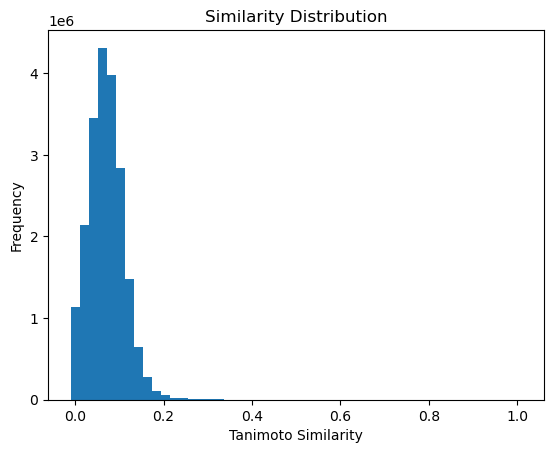

In [33]:
import matplotlib.pyplot as plt

bins = len(hist)
x = np.linspace(0, 1, bins)

plt.figure()
plt.bar(x, hist, width=1/bins)
plt.xlabel("Tanimoto Similarity")
plt.ylabel("Frequency")
plt.title("Similarity Distribution")
plt.show()